READ IN DATA

In [1]:
!pip install cfbd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 330.3/330.3 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.13.4
    Uninstalling pydantic-2.13.4:
      Successfully uninstalled pydantic-2.13.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langgraph 1.2.11 requires pydantic>=2.7.4, but you have pydantic 1.10.26 which is incompatible.
gradio 6.24.0 requires pydantic<=3.0,>=2.0, but you have pydantic 1.10.26 which is incompatible.
weasel 1.0.0 requires pydantic>=2.0.0, but you have pydantic 1.10.26 which is incompatible.
langsmith 0.11.0 requires pydantic<3,>=2, but you have pyd

In [2]:
from google.colab import userdata
import cfbd
access_token = userdata.get('CFBD_API_KEY')
configuration = cfbd.Configuration(access_token=access_token)

api_client = cfbd.ApiClient(configuration)
teams_api = cfbd.TeamsApi(api_client)

In [3]:
import pandas as pd

teams_api = cfbd.TeamsApi(api_client)
records_api = cfbd.GamesApi(api_client)
years = [2022, 2023, 2024, 2025]
all_fbs_records = []

for year in years:
    # get fbs teams for the specific year
    teams = teams_api.get_teams(year=year)
    fbs_teams = [t.school for t in teams if t.classification == "fbs"]
    print(f"{year}: {len(fbs_teams)} FBS teams")

    # get records for this year, filtered to that year's fbs list
    records = records_api.get_records(year=year)
    fbs_records = [r for r in records if r.team in fbs_teams]

    all_fbs_records.extend(fbs_records)

print(f"Total records across all years: {len(all_fbs_records)}")

2022: 131 FBS teams
2023: 133 FBS teams
2024: 134 FBS teams
2025: 136 FBS teams
Total records across all years: 534


In [4]:
records_api = cfbd.GamesApi(api_client)
all_records = records_api.get_records(year=2024)

fbs_records = [r for r in all_records if r.team in fbs_teams]
print(len(fbs_records))

136


MERGE INTO DATAFRAME

In [5]:
# consolidate all years into a dataframe
df = pd.DataFrame([r.to_dict() for r in all_fbs_records])
df.tail()

,year,teamId,team,classification,conference,division,expectedWins,total,conferenceGames,homeGames,awayGames,neutralSiteGames,regularSeason,postseason
529,2025,2247,Georgia State,DivisionClassification.FBS,Sun Belt,East,1.962546,"{'games': 12, 'wins': 1, 'losses': 11, 'ties': 0}","{'games': 8, 'wins': 0, 'losses': 8, 'ties': 0}","{'games': 6, 'wins': 1, 'losses': 5, 'ties': 0}","{'games': 6, 'wins': 0, 'losses': 6, 'ties': 0}","{'games': 0, 'wins': 0, 'losses': 0, 'ties': 0}","{'games': 12, 'wins': 1, 'losses': 11, 'ties': 0}","{'games': 0, 'wins': 0, 'losses': 0, 'ties': 0}"
530,2025,5,UAB,DivisionClassification.FBS,American Athletic,,2.943400,"{'games': 12, 'wins': 4, 'losses': 8, 'ties': 0}","{'games': 8, 'wins': 2, 'losses': 6, 'ties': 0}","{'games': 6, 'wins': 3, 'losses': 3, 'ties': 0}","{'games': 6, 'wins': 1, 'losses': 5, 'ties': 0}","{'games': 0, 'wins': 0, 'losses': 0, 'ties': 0}","{'games': 12, 'wins': 4, 'losses': 8, 'ties': 0}","{'games': 0, 'wins': 0, 'losses': 0, 'ties': 0}"
531,2025,151,East Carolina,DivisionClassification.FBS,American Athletic,,8.686513,"{'games': 13, 'wins': 9, 'losses': 4, 'ties': 0}","{'games': 8, 'wins': 6, 'losses': 2, 'ties': 0}","{'games': 6, 'wins': 5, 'losses': 1, 'ties': 0}","{'games': 6, 'wins': 3, 'losses': 3, 'ties': 0}","{'games': 1, 'wins': 1, 'losses': 0, 'ties': 0}","{'games': 12, 'wins': 8, 'losses': 4, 'ties': 0}","{'games': 1, 'wins': 1, 'losses': 0, 'ties': 0}"
532,2025,2641,Texas Tech,DivisionClassification.FBS,Big 12,,11.977661,"{'games': 14, 'wins': 12, 'losses': 2, 'ties': 0}","{'games': 9, 'wins': 8, 'losses': 1, 'ties': 0}","{'games': 7, 'wins': 7, 'losses': 0, 'ties': 0}","{'games': 5, 'wins': 4, 'losses': 1, 'ties': 0}","{'games': 2, 'wins': 1, 'losses': 1, 'ties': 0}","{'games': 13, 'wins': 12, 'losses': 1, 'ties': 0}","{'games': 1, 'wins': 0, 'losses': 1, 'ties': 0}"
533,2025,201,Oklahoma,DivisionClassification.FBS,SEC,,8.677019,"{'games': 13, 'wins': 10, 'losses': 3, 'ties': 0}","{'games': 8, 'wins': 6, 'losses': 2, 'ties': 0}","{'games': 8, 'wins': 6, 'losses': 2, 'ties': 0}","{'games': 4, 'wins': 4, 'losses': 0, 'ties': 0}","{'games': 1, 'wins': 0, 'losses': 1, 'ties': 0}","{'games': 12, 'wins': 10, 'losses': 2, 'ties': 0}","{'games': 1, 'wins': 0, 'losses': 1, 'ties': 0}"


In [6]:
# check column heads
print(df.columns.tolist())

# check for nulls
df.isnull().sum()
df['conference'].unique()

['year', 'teamId', 'team', 'classification', 'conference', 'division', 'expectedWins', 'total', 'conferenceGames', 'homeGames', 'awayGames', 'neutralSiteGames', 'regularSeason', 'postseason']


array(['Mid-American', 'Sun Belt', 'ACC', 'FBS Independents', 'Pac-12',
       'Conference USA', 'Mountain West', 'American Athletic', 'SEC',
       'Big Ten', 'Big 12'], dtype=object)

In [7]:
# define power/mid-major split
def classify(row):
    conf = row['conference']
    year = row['year']
    team = row['team']

    power_conferences = ['ACC', 'Big Ten', 'Big 12', 'SEC']
    mid_major_conferences = ['American Athletic', 'Conference USA', 'Mid-American', 'Mountain West', 'Sun Belt']

    # handle independents by team name
    if team == 'Notre Dame':
        return 'power'
    if team == 'UConn':
        return 'mid-major'
    if team == 'Army':
        return 'mid-major'
    if team == 'Liberty':
        return 'mid-major'
    if team == 'New Mexico State':
        return 'mid-major'
    if team == 'Massachusetts':
        return 'mid-major'
    if team == 'BYU' and year == 2022:
        return 'mid-major'

    # handle pac-12's collapse as a clean year cutoff
    if conf == 'Pac-12':
        return 'power' if year <= 2023 else 'mid-major'

    if conf in power_conferences:
        return 'power'
    elif conf in mid_major_conferences:
        return 'mid-major'
    else:
        return 'unclassified'

df['group'] = df.apply(classify, axis=1)
df['group'].value_counts()

,count
group,
power,270
mid-major,264


In [8]:
games_api = cfbd.GamesApi(api_client)
all_postseason_games = []

for year in years:
    games = games_api.get_games(year=year, season_type='postseason')
    all_postseason_games.extend(games)

games_df = pd.DataFrame([g.to_dict() for g in all_postseason_games])
print(games_df.shape)
print(games_df.columns.tolist())
games_df.head()

(327, 34)
['id', 'season', 'week', 'seasonType', 'startDate', 'startTimeTBD', 'completed', 'neutralSite', 'conferenceGame', 'attendance', 'venueId', 'venue', 'homeId', 'homeTeam', 'homeConference', 'homeClassification', 'homePoints', 'homeLineScores', 'homePostgameWinProbability', 'homePregameElo', 'homePostgameElo', 'awayId', 'awayTeam', 'awayConference', 'awayClassification', 'awayPoints', 'awayLineScores', 'awayPostgameWinProbability', 'awayPregameElo', 'awayPostgameElo', 'excitementIndex', 'highlights', 'notes', 'playoff']


,id,season,week,seasonType,startDate,startTimeTBD,completed,neutralSite,conferenceGame,attendance,...,awayClassification,awayPoints,awayLineScores,awayPostgameWinProbability,awayPregameElo,awayPostgameElo,excitementIndex,highlights,notes,playoff
0,401441993,2022,1,SeasonType.POSTSEASON,2022-12-16 16:30:00+00:00,False,True,True,False,12172.0,...,DivisionClassification.FBS,20,"[0, 6, 7, 7]",0.172821,1382.0,1380.0,5.888482,,HomeTown Lenders Bahamas Bowl,None
1,401441994,2022,1,SeasonType.POSTSEASON,2022-12-16 20:00:00+00:00,False,True,True,False,NaN,...,DivisionClassification.FBS,12,"[2, 10, 0, 0]",0.844326,1679.0,1658.0,8.305433,,Duluth Trading Cure Bowl,None
2,401508871,2022,1,SeasonType.POSTSEASON,2022-12-17 00:00:00+00:00,False,True,True,False,NaN,...,DivisionClassification.III,21,"[0, 0, 0, 21]",NaN,NaN,NaN,NaN,,Division III Championship,None
3,401508850,2022,1,SeasonType.POSTSEASON,2022-12-17 00:00:00+00:00,False,True,False,False,NaN,...,DivisionClassification.FCS,32,"[16, 0, 13, 3]",0.868965,NaN,NaN,7.710492,,FCS Championship - Semifinals,None
4,401441995,2022,1,SeasonType.POSTSEASON,2022-12-17 16:00:00+00:00,False,True,True,False,NaN,...,DivisionClassification.FBS,7,"[0, 7, 0, 0]",0.003283,1739.0,1690.0,4.044241,,Wasabi Fenway Bowl,None


In [9]:
# filter games_df to fbs games only, then reshape into one row per team per game
fbs_games_df = games_df[
    (games_df['homeClassification'] == 'fbs') | (games_df['awayClassification'] == 'fbs')]

home_appearances = fbs_games_df[fbs_games_df['homeClassification'] == 'fbs'][['season', 'homeTeam']].rename(columns={'homeTeam': 'team'})
away_appearances = fbs_games_df[fbs_games_df['awayClassification'] == 'fbs'][['season', 'awayTeam']].rename(columns={'awayTeam': 'team'})

appearances = pd.concat([home_appearances, away_appearances], ignore_index=True)
appearances = appearances.drop_duplicates(subset=['season', 'team'])

print(appearances.shape)
appearances.head()

(328, 2)


,season,team
0,2022,UAB
1,2022,Troy
2,2022,Louisville
3,2022,Oregon State
4,2022,Fresno State


In [10]:
appearances['year'] = appearances['season']
# merge conference information from the main 'df' into 'appearances'
appearances = appearances.merge(df[['year', 'team', 'conference']].drop_duplicates(), on=['year', 'team'], how='left')
appearances['group'] = appearances.apply(classify, axis=1)
appearances['group'].value_counts()

,count
group,
power,182
mid-major,146


In [11]:
unmatched = appearances[appearances['conference'].isnull()]['team'].unique()
print(sorted(unmatched))

[]


ANALYZE WIN PERCENTAGE

In [12]:
total_df = pd.json_normalize(df['total'])
total_df.columns = ['total_' + c for c in total_df.columns]
df = pd.concat([df, total_df], axis=1)

print(df.columns.tolist())
df[['team', 'year', 'total_wins', 'total_losses']].head()

['year', 'teamId', 'team', 'classification', 'conference', 'division', 'expectedWins', 'total', 'conferenceGames', 'homeGames', 'awayGames', 'neutralSiteGames', 'regularSeason', 'postseason', 'group', 'total_games', 'total_wins', 'total_losses', 'total_ties']


,team,year,total_wins,total_losses
0,Kent State,2022,5,7
1,Eastern Michigan,2022,9,4
2,UL Monroe,2022,4,8
3,Georgia Tech,2022,5,7
4,Coastal Carolina,2022,9,4


In [13]:
df.to_csv('data.csv')

INSERT RECRUITING DATA

In [14]:
import cfbd
import pandas as pd
import os

# access_token and api_client already configured in a previous cell
# configuration = cfbd.Configuration(
#     access_token = os.environ["CFBD_API_KEY"])

recruit_records = []
with cfbd.ApiClient(configuration) as api_client_for_recruiting:
    recruiting_api = cfbd.RecruitingApi(api_client_for_recruiting)
    for year in [2023, 2024, 2025, 2026]:
        recruits = recruiting_api.get_recruits(year=year)
        recruit_records.extend([r.to_dict() for r in recruits])

recruits_df = pd.DataFrame(recruit_records)
recruits_df.head()

,id,athleteId,recruitType,year,ranking,name,school,committedTo,position,height,weight,stars,rating,city,stateProvince,country,hometownInfo
0,111247,4870906,RecruitClassification.HIGHSCHOOL,2023,1.0,Arch Manning,Isidore Newman,Texas,QB,76.0,215.0,5.0,0.9995,New Orleans,LA,USA,"{'fipsCode': '22071', 'longitude': -90.0701156..."
1,111248,4870879,RecruitClassification.HIGHSCHOOL,2023,2.0,Keon Keeley,Berkeley Prep,Alabama,EDGE,77.0,242.0,5.0,0.9984,Tampa,FL,USA,"{'fipsCode': '12057', 'longitude': -82.458444,..."
2,111249,4870799,RecruitClassification.HIGHSCHOOL,2023,3.0,Nico Iamaleava,Warren,Tennessee,QB,77.0,195.0,5.0,0.9980,Long Beach,CA,USA,"{'fipsCode': '06037', 'longitude': -118.191604..."
3,111251,None,RecruitClassification.HIGHSCHOOL,2023,4.0,Zachariah Branch,Bishop Gorman,USC,WR,70.0,172.0,5.0,0.9980,Las Vegas,NV,USA,"{'fipsCode': '32003', 'longitude': -115.148516..."
4,111250,4686995,RecruitClassification.HIGHSCHOOL,2023,5.0,Dante Moore,Martin Luther King,UCLA,QB,74.5,210.0,5.0,0.9977,Detroit,MI,USA,"{'fipsCode': '26163', 'longitude': -83.0466403..."


In [15]:
portal_records = []
with cfbd.ApiClient(configuration) as api_client:
    players_api = cfbd.PlayersApi(api_client)
    for year in [2023, 2024, 2025, 2026]:
        portal = players_api.get_transfer_portal(year=year)
        portal_records.extend([p.to_dict() for p in portal])

portal_df = pd.DataFrame(portal_records)
portal_df.head()

,season,firstName,lastName,position,origin,destination,transferDate,stars,eligibility,rating
0,2023,Jamar,Rucks,DL,App State,Kennesaw State,2022-12-05 11:46:00+00:00,3.0,TransferEligibility.IMMEDIATE,NaN
1,2023,Joshua,Farmer,DL,Florida State,None,2023-04-27 17:23:00+00:00,3.0,TransferEligibility.IMMEDIATE,NaN
2,2023,A'Jon,Vivens,RB,Colorado State,None,2022-10-31 21:23:00+00:00,3.0,TransferEligibility.IMMEDIATE,NaN
3,2023,Michael,Mack,CB,Air Force,None,2023-06-19 12:16:00+00:00,2.0,TransferEligibility.PENDINGAPPEAL,NaN
4,2023,Nate,Jefferson,WR,Florida International,None,2023-07-06 22:31:00+00:00,3.0,TransferEligibility.IMMEDIATE,NaN


ANALYZE TRANSFER PORTAL DATA

In [16]:
# only players who actually landed somewhere
landed = portal_df.dropna(subset=['destination'])

# count of incoming transfers by destination school per year
dest_by_year = (
    landed.groupby(['season', 'destination'])
    .size()
    .reset_index(name='transfers_in'))

# top 10 destinations for each year
for year in sorted(landed['season'].unique()):
    print(f"\n{year} — Top Transfer Destinations")
    print(
        dest_by_year[dest_by_year['season'] == year]
        .sort_values('transfers_in', ascending=False)
        .head(10)
        .to_string(index=False))


2023 — Top Transfer Destinations
 season   destination  transfers_in
   2023      Colorado            48
   2023   Texas State            37
   2023 Arizona State            30
   2023    Louisville            26
   2023           SMU            26
   2023      Ole Miss            25
   2023       Indiana            23
   2023        Auburn            21
   2023 Massachusetts            21
   2023    Cincinnati            21

2024 — Top Transfer Destinations
 season   destination  transfers_in
   2024      Colorado            41
   2024 Georgia State            31
   2024       Memphis            30
   2024       Indiana            30
   2024   Texas State            30
   2024 Massachusetts            29
   2024    Louisville            28
   2024     Charlotte            28
   2024    New Mexico            28
   2024      Marshall            28

2025 — Top Transfer Destinations
 season      destination  transfers_in
   2025         Marshall            52
   2025    Southern Miss    

In [17]:
# top transfer destinations by tier
# team to conference per year (2023-2026)
all_team_records = []
with cfbd.ApiClient(configuration) as api_client:
    teams_api = cfbd.TeamsApi(api_client)
    for year in [2023, 2024, 2025, 2026]:
        teams = teams_api.get_teams(year=year)
        all_team_records.extend([
            {'year': year, 'team': t.school, 'conference': t.conference, 'classification': t.classification}
            for t in teams])

all_team_df = pd.DataFrame(all_team_records)

In [18]:
# same classify() logic as win-loss data
def classify(team, year, conference):
    if team == 'Notre Dame':
        return 'power'
    if team == 'UConn':
        return 'mid-major'
    if team == 'BYU':
        return 'mid-major' if year == 2022 else 'power'
    if conference == 'Pac-12':
        return 'power' if year <= 2023 else 'mid-major'
    if conference in ['ACC', 'Big Ten', 'Big 12', 'SEC']:
        return 'power'
    return 'mid-major'

all_team_df['tier'] = all_team_df.apply(lambda r: classify(r['team'], r['year'], r['conference']), axis=1)
tier_lookup = all_team_df.set_index(['team', 'year'])['tier'].to_dict()

In [19]:
def classify_full(team, year, conference, classification):
    if classification != 'fbs':
        return 'non-FBS'
    return classify(team, year, conference)  # your existing function

all_team_df['tier'] = all_team_df.apply(
    lambda r: classify_full(r['team'], r['year'], r['conference'], r['classification']), axis=1)
tier_lookup = all_team_df.set_index(['team', 'year'])['tier'].to_dict()

portal_df['origin_tier'] = portal_df.apply(lambda r: tier_lookup.get((r['origin'], r['season'])), axis=1)
portal_df['destination_tier'] = portal_df.apply(
    lambda r: tier_lookup.get((r['destination'], r['season'])) if pd.notna(r['destination']) else None, axis=1)
print('Unmatched origin:', portal_df['origin_tier'].isna().sum())
print('Unmatched destination (excl. blanks):', portal_df[portal_df['destination'].notna() & portal_df['destination_tier'].isna()].shape[0])

Unmatched origin: 170
Unmatched destination (excl. blanks): 187


In [20]:
portal_df['origin_tier'] = portal_df['origin_tier'].fillna('unknown/non-D1')
portal_df['destination_tier'] = portal_df['destination_tier'].fillna('unknown/non-D1')

In [21]:
# track where 3+-star players are moving
landed = portal_df.dropna(subset=['destination'])
star_flow = (
    landed[landed['stars'] >= 3]
    .groupby(['season', 'origin_tier', 'destination_tier'])
    .size()
    .unstack('destination_tier'))
print(star_flow.fillna(0).astype(int).to_string())
# number of transfers to power has boomed since 2025, even between power teams

destination_tier       mid-major  non-FBS  power  unknown/non-D1
season origin_tier                                              
2023   mid-major             116       64    183               5
       non-FBS                25        4     89               1
       power                 310       75    515               5
       unknown/non-D1          1        0      6               0
2024   mid-major             271      208    271              16
       non-FBS               180       17    116               0
       power                 471      133    597              10
       unknown/non-D1         11        0      4               0
2025   mid-major             424      277    424              33
       non-FBS               268       37    206               5
       power                 527      163    703              14
       unknown/non-D1         15        0     14               1
2026   mid-major             360      122    460               9
       non-FBS           

ANALYZE RECRUIT PORTFOLIO

In [22]:
# check committed-team column name
print(recruits_df.columns.tolist())
recruits_df[['year', 'stars', 'committedTo']].head()

['id', 'athleteId', 'recruitType', 'year', 'ranking', 'name', 'school', 'committedTo', 'position', 'height', 'weight', 'stars', 'rating', 'city', 'stateProvince', 'country', 'hometownInfo']


,year,stars,committedTo
0,2023,5.0,Texas
1,2023,5.0,Alabama
2,2023,5.0,Tennessee
3,2023,5.0,USC
4,2023,5.0,UCLA


In [23]:
star_recruits = recruits_df[recruits_df['stars'] >= 3].copy()
star_recruits['committed_tier'] = star_recruits.apply(
    lambda r: tier_lookup.get((r['committedTo'], r['year'])), axis=1)
star_recruits['committed_tier'] = star_recruits['committed_tier'].fillna('unknown/non-D1')

recruit_dist = (
    star_recruits.groupby(['year', 'committed_tier'])
    .size()
    .unstack('committed_tier')
    .fillna(0)
    .astype(int))
print(recruit_dist.to_string())

committed_tier  mid-major  non-FBS  power  unknown/non-D1
year                                                     
2023                  752      248   1421             239
2024                  978      314   1396             278
2025                 1069      370   1494             284
2026                 1270      307   1536             282


In [24]:
# share of 3+-star class per destination
recruit_share = recruit_dist.div(recruit_dist.sum(axis=1), axis=0) * 100
print(recruit_share.round(1).to_string())

committed_tier  mid-major  non-FBS  power  unknown/non-D1
year                                                     
2023                 28.3      9.3   53.4             9.0
2024                 33.0     10.6   47.1             9.4
2025                 33.2     11.5   46.4             8.8
2026                 37.4      9.0   45.2             8.3


In [25]:
star_breakdown = (
    star_recruits.groupby(['year', 'stars', 'committed_tier'])
    .size()
    .unstack('committed_tier')
    .fillna(0)
    .astype(int))
print(star_breakdown.to_string())

committed_tier  mid-major  non-FBS  power  unknown/non-D1
year stars                                               
2023 3.0              750      248    974             237
     4.0                2        0    408               1
     5.0                0        0     39               1
2024 3.0              972      312    924             278
     4.0                6        2    435               0
     5.0                0        0     37               0
2025 3.0             1066      370   1020             284
     4.0                3        0    442               0
     5.0                0        0     32               0
2026 3.0             1264      307   1054             282
     4.0                6        0    445               0
     5.0                0        0     37               0


In [26]:
# percentage star breakdown per tier
star_breakdown_share = star_breakdown.div(star_breakdown.sum(axis=1), axis=0) * 100
print(star_breakdown_share.round(1).to_string())

committed_tier  mid-major  non-FBS  power  unknown/non-D1
year stars                                               
2023 3.0             34.0     11.2   44.1            10.7
     4.0              0.5      0.0   99.3             0.2
     5.0              0.0      0.0   97.5             2.5
2024 3.0             39.1     12.6   37.2            11.2
     4.0              1.4      0.5   98.2             0.0
     5.0              0.0      0.0  100.0             0.0
2025 3.0             38.9     13.5   37.2            10.4
     4.0              0.7      0.0   99.3             0.0
     5.0              0.0      0.0  100.0             0.0
2026 3.0             43.5     10.6   36.3             9.7
     4.0              1.3      0.0   98.7             0.0
     5.0              0.0      0.0  100.0             0.0


In [27]:
# 3+-star gap
gap_by_year = recruit_share['power'] - recruit_share['mid-major']
print('\nPower minus mid-major share of 3+ star class by year:')
print(gap_by_year.round(1).to_string())


Power minus mid-major share of 3+ star class by year:
year
2023    25.2
2024    14.1
2025    13.2
2026     7.8


In [28]:
elite_recruits = recruits_df[recruits_df['stars'] >= 4].copy()
elite_recruits['committed_tier'] = elite_recruits.apply(
    lambda r: tier_lookup.get((r['committedTo'], r['year'])), axis=1)
elite_recruits['committed_tier'] = elite_recruits['committed_tier'].fillna('unknown/non-D1')
elite_dist = (
    elite_recruits.groupby(['year', 'committed_tier'])
    .size()
    .unstack('committed_tier')
    .fillna(0)
    .astype(int))
elite_share = elite_dist.div(elite_dist.sum(axis=1), axis=0) * 100
elite_gap_by_year = elite_share['power'] - elite_share['mid-major']
print('\nPower minus mid-major share of 4-/5-star class by year:')
print(elite_gap_by_year.round(1).to_string())


Power minus mid-major share of 4-/5-star class by year:
year
2023    98.7
2024    97.1
2025    98.7
2026    97.5


VISUALIZE RECRUITING DATA

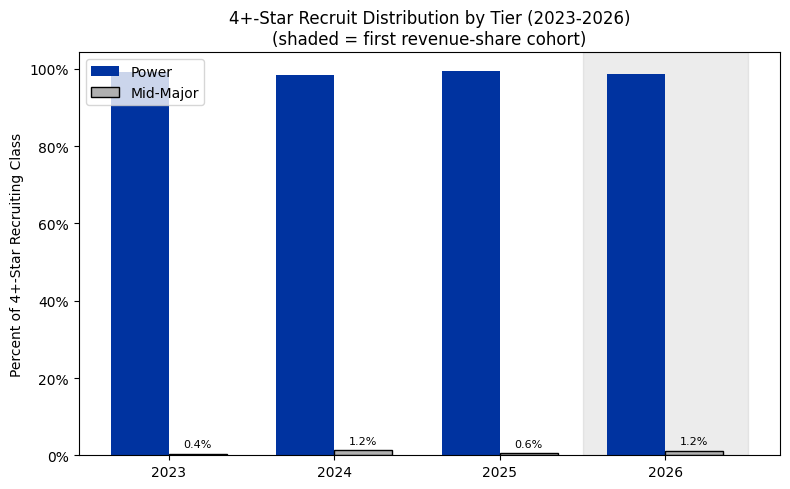

In [29]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

REVSHARE_YEAR = 2026
TIER_COLORS = {'power': '#0033A0', 'mid-major': '#B0B0B0'}

years = elite_share.index.tolist()
width = 0.35
x = list(range(len(years)))
power_vals = elite_share['power'].values
midmajor_vals = elite_share['mid-major'].values
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width / 2 for i in x], power_vals, width, label='Power', color=TIER_COLORS['power'])
rects2 = ax.bar([i + width / 2 for i in x], midmajor_vals, width, label='Mid-Major', color=TIER_COLORS['mid-major'], edgecolor='black', linewidth=1)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

# shade the 2026 group to flag the first revenue-share cohort
if REVSHARE_YEAR in years:
    idx = years.index(REVSHARE_YEAR)
    ax.axvspan(idx - 0.5, idx + 0.5, color='gray', alpha=0.15, zorder=0)
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylabel('Percent of 4+-Star Recruiting Class')
ax.set_title('4+-Star Recruit Distribution by Tier (2023-2026)\n(shaded = first revenue-share cohort)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

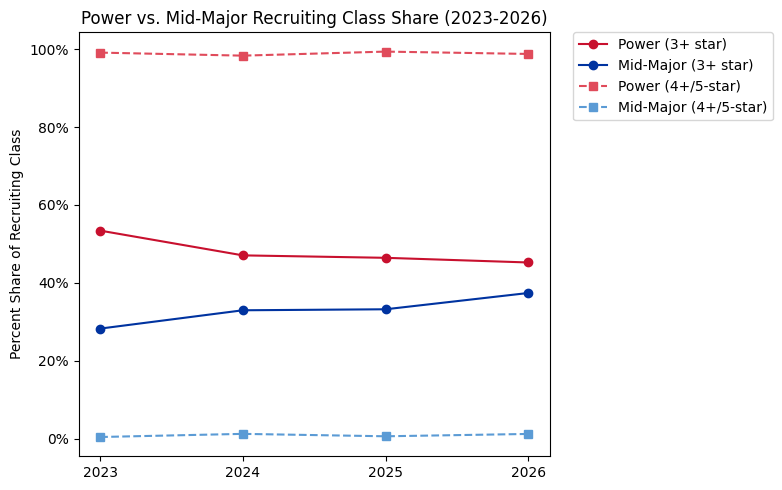

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

# plot actual shares for 3+ star recruits
ax.plot(recruit_share.index, recruit_share['power'].values, marker='o', label='Power (3+ star)', color='#C8102E')
ax.plot(recruit_share.index, recruit_share['mid-major'].values, marker='o', label='Mid-Major (3+ star)', color='#0033A0')

# plot actual shares for 4+-star recruits
ax.plot(elite_share.index, elite_share['power'].values, marker='s', label='Power (4+/5-star)', color='#E04B5B', linestyle='--')
ax.plot(elite_share.index, elite_share['mid-major'].values, marker='s', label='Mid-Major (4+/5-star)', color='#5B9BD5', linestyle='--')
ax.set_xticks(sorted(set(recruit_share.index) | set(elite_share.index)))
ax.set_ylabel('Percent Share of Recruiting Class')
ax.set_title('Power vs. Mid-Major Recruiting Class Share (2023-2026)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()

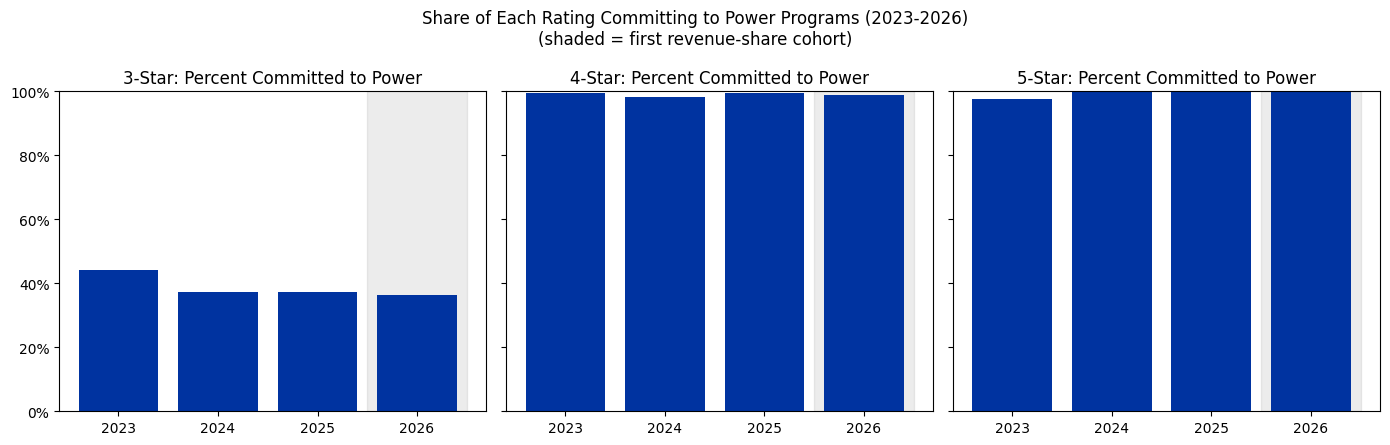

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)
for ax, stars in zip(axes, [3, 4, 5]):
    subset = star_breakdown_share.xs(stars, level='stars')['power']
    subset_years = subset.index.tolist()
    ax.bar([str(y) for y in subset_years], subset.values, color=TIER_COLORS['power'])
    if REVSHARE_YEAR in subset_years:
        idx = subset_years.index(REVSHARE_YEAR)
        ax.axvspan(idx - 0.5, idx + 0.5, color='gray', alpha=0.15, zorder=0)
    ax.set_title(f'{stars}-Star: Percent Committed to Power')
    ax.set_ylim(0, 100)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())

fig.suptitle('Share of Each Rating Committing to Power Programs (2023-2026)\n(shaded = first revenue-share cohort)')
plt.tight_layout()
plt.show()

CONVERT TO HTML

In [32]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!pip install nbconvert

notebook_filename = "/content/drive/MyDrive/Colab Notebooks/fbs_gap.ipynb"
output_html_filename = "fbs_gap.html"

!jupyter nbconvert --to html --output "{output_html_filename}" "{notebook_filename}" --template full

print(f"Notebook converted (outputs preserved, not re-executed). Output saved to '/content/{output_html_filename}'.")

NameError: name 'drive' is not defined